In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

from utils import plot_style
from utils.plot_helpers import (
    plot_conflict_agreement,
    plot_agreement_mediation_event_studies,
)


# Outline

- [Country Panel Analysis](#country-panel-analysis)
  - [Figure 1: Conflict fatalities and agreement timing](#figure-1-conflict-fatalities-and-agreement-timing)
  - [Figure 2: Event study around agreement month](#figure-2-event-study-around-agreement-month)
- [Conflict Panel Analysis](#conflict-panel-analysis)


# Country Panel Analysis


This section summarizes country-level patterns in conflict fatalities and agreement timing.


In [2]:
df_country = pd.read_csv('../../data/output/country_level/country_panel.csv', low_memory=False)
df_country["year_mo"] = pd.to_datetime(df_country["year_mo"])
df_country.head()


,Unnamed: 0,isocode,year_mo,country,best,n_conflicts,n_events,region,subregion,agreement,...,cea_agreement_active,agreement_no_ceasefire,treated_agreements_no_ceasefire,agreement_no_ceasefire_mentions_agreement_6m,comp_agreement_no_ceasefire,treated_comp_agreements_no_ceasefire,comp_agreement_no_ceasefire_mentions_agreement_6m,subs_agreement_no_ceasefire,treated_subs_agreements_no_ceasefire,subs_agreement_no_ceasefire_mentions_agreement_6m
0,0,AFG,1989-01-01,Afghanistan,693.75,1.0,13.0,Asia,Southern Asia,0,...,0,0,1,0,0,0,0,0,1,0
1,1,AFG,1989-02-01,Afghanistan,162.75,1.0,18.0,Asia,Southern Asia,0,...,0,0,1,0,0,0,0,0,1,0
2,2,AFG,1989-03-01,Afghanistan,1745.75,1.0,21.0,Asia,Southern Asia,0,...,0,0,1,0,0,0,0,0,1,0
3,3,AFG,1989-04-01,Afghanistan,495.75,1.0,28.0,Asia,Southern Asia,0,...,0,0,1,0,0,0,0,0,1,0
4,4,AFG,1989-05-01,Afghanistan,441.00,1.0,18.0,Asia,Southern Asia,0,...,0,0,1,0,0,0,0,0,1,0


## Figure 1: Conflict fatalities and agreement timing
The figure contrasts monthly conflict fatalities with the timing of agreements for selected countries.


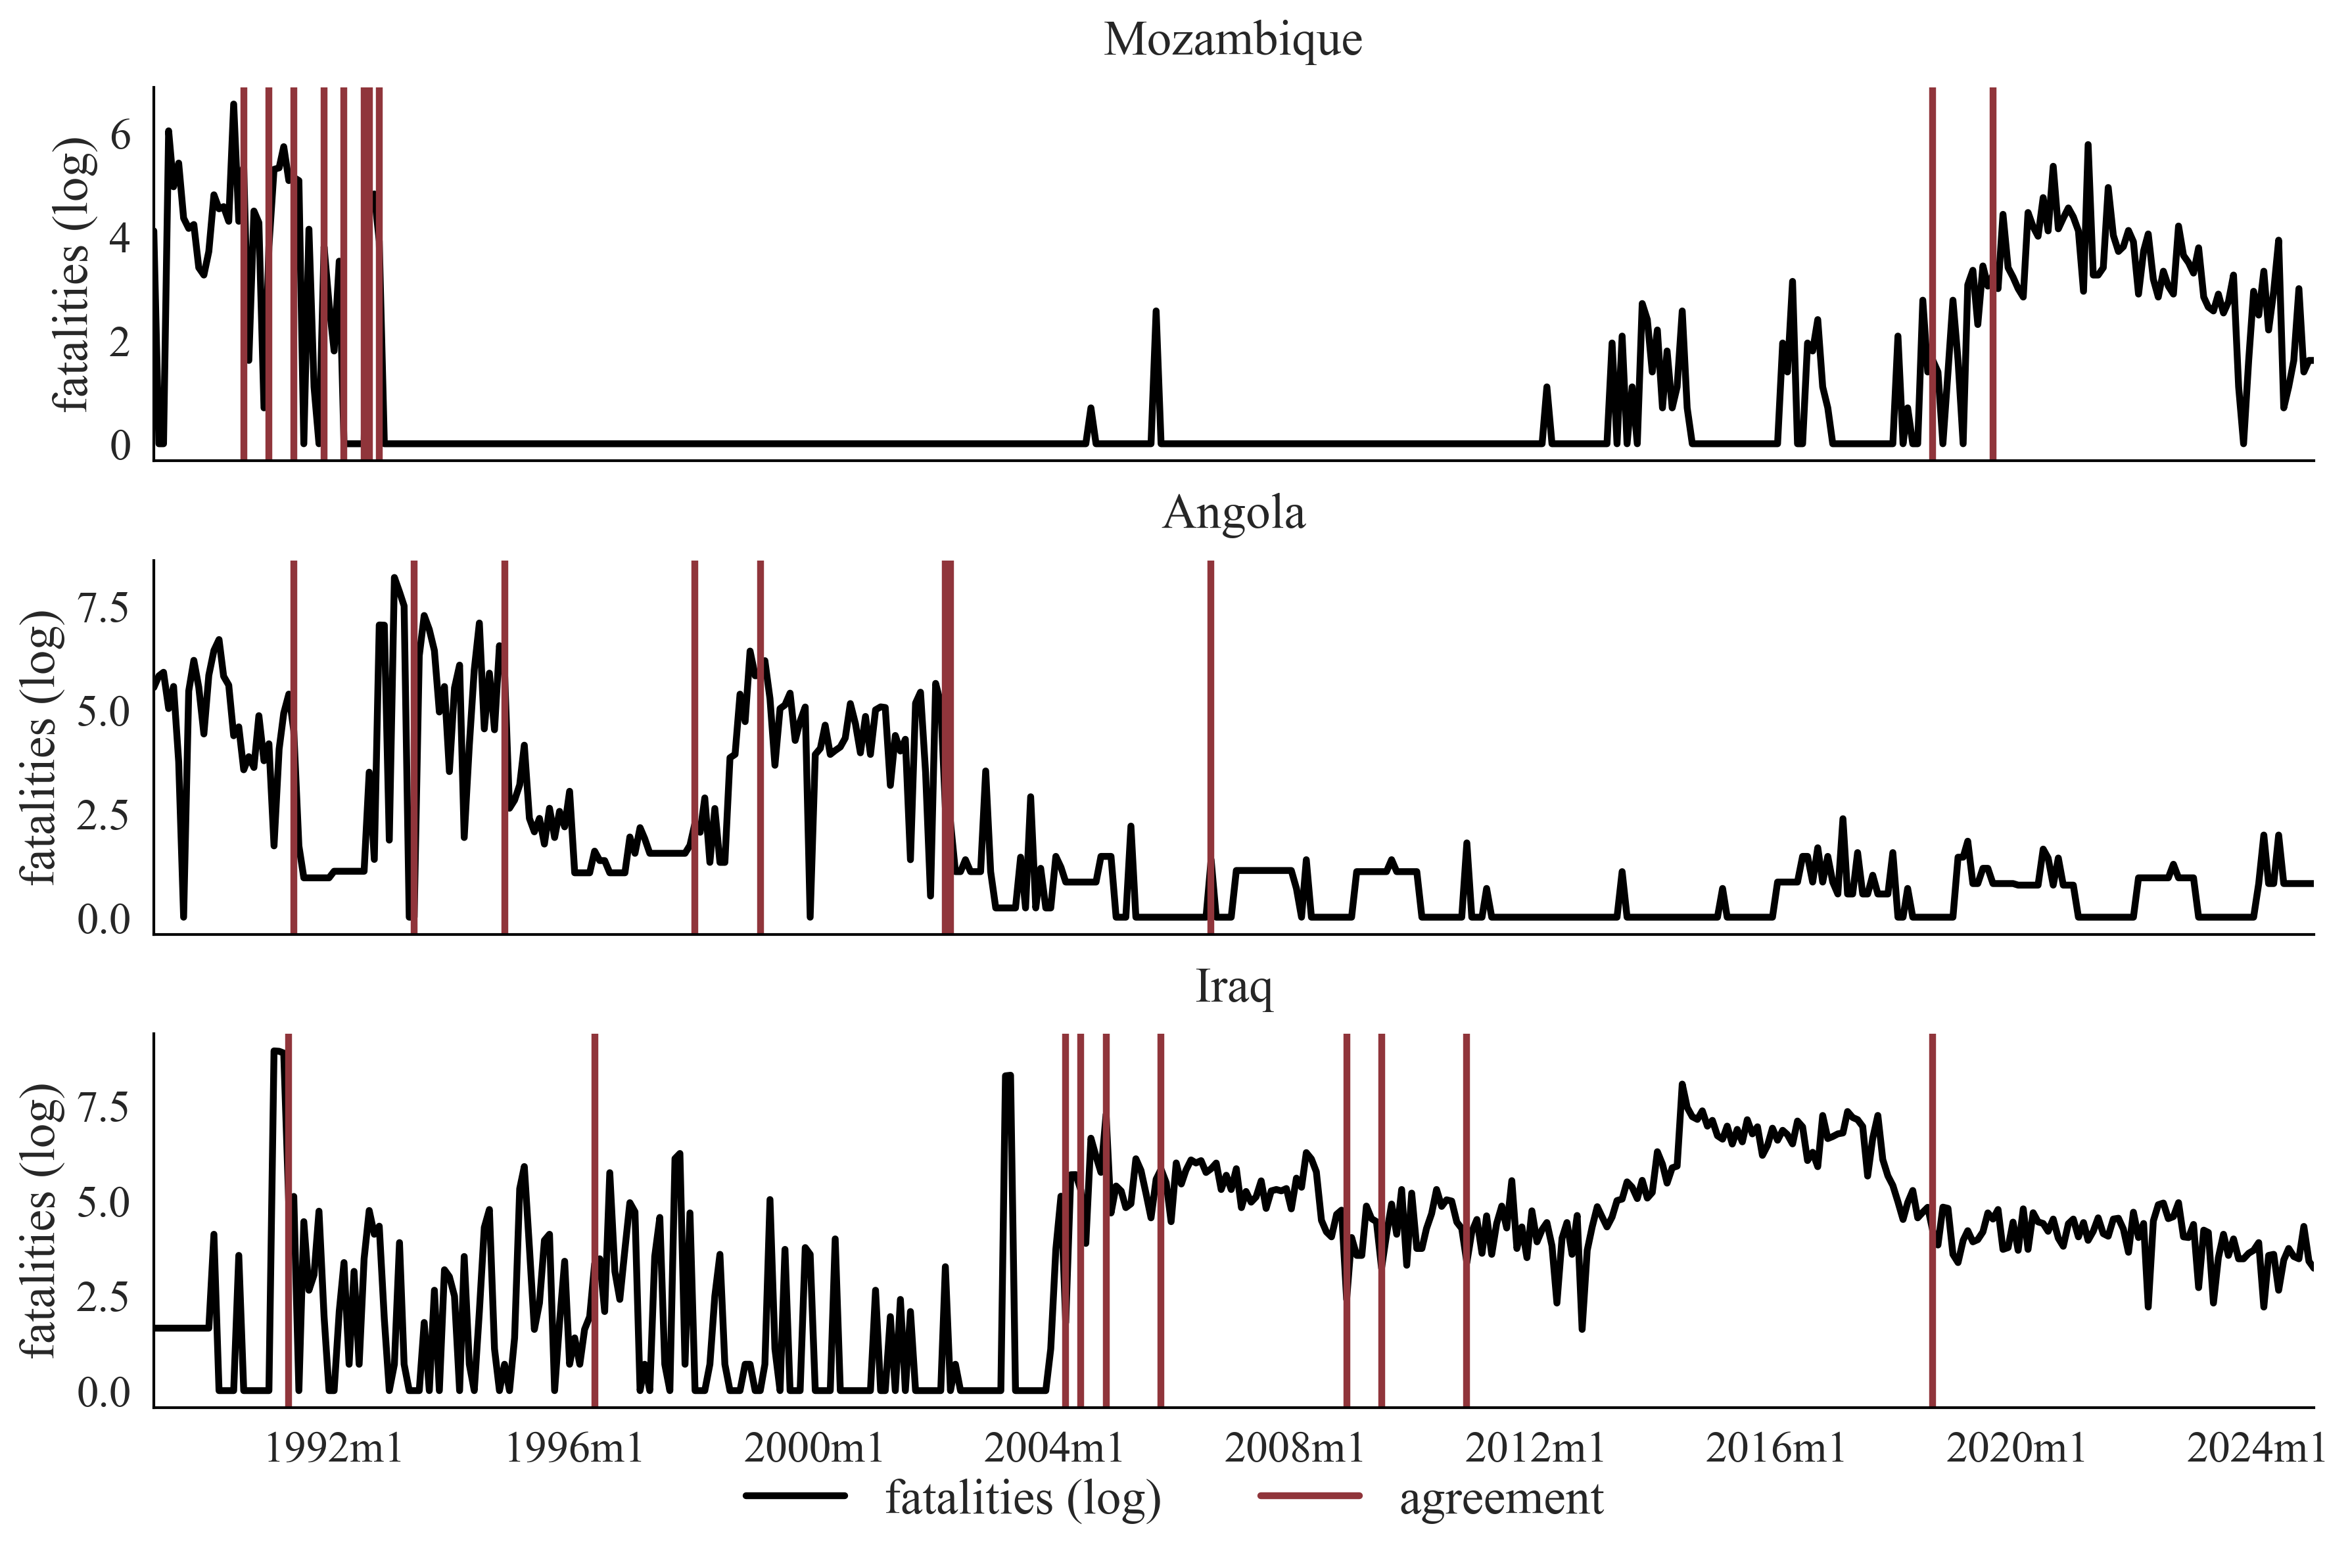

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True, sharey=False)

countries = [
    ("Mozambique", "MOZ"),
    ("Angola", "AGO"),
    ("Iraq", "IRQ"),
]

# Plot each country
for ax, (country, iso) in zip(axes.flatten(), countries):
    plot_conflict_agreement(df_country, country, iso, ax)

# Create custom legend handles
main_line = mlines.Line2D([], [], color='black', linewidth=2.5, label='fatalities (log)')
agreement_patch = mlines.Line2D([], [], color='#90353B', linewidth=2.5, linestyle='-', label='agreement')

# Add legend for whole figure (bottom center)
fig.legend(
    handles=[main_line, agreement_patch],
    loc='lower center',
    ncol=3,           # spread legend items in a row
    frameon=False,
    fontsize=18
)

plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave space at bottom for legend
fig.savefig("figures/figure_conflict_3x1.png", format="png", bbox_inches="tight")
plt.show()


## Figure 2: Event study around agreement month
This plot shows average fatalities in the months surrounding agreement dates, with 95% confidence bands.


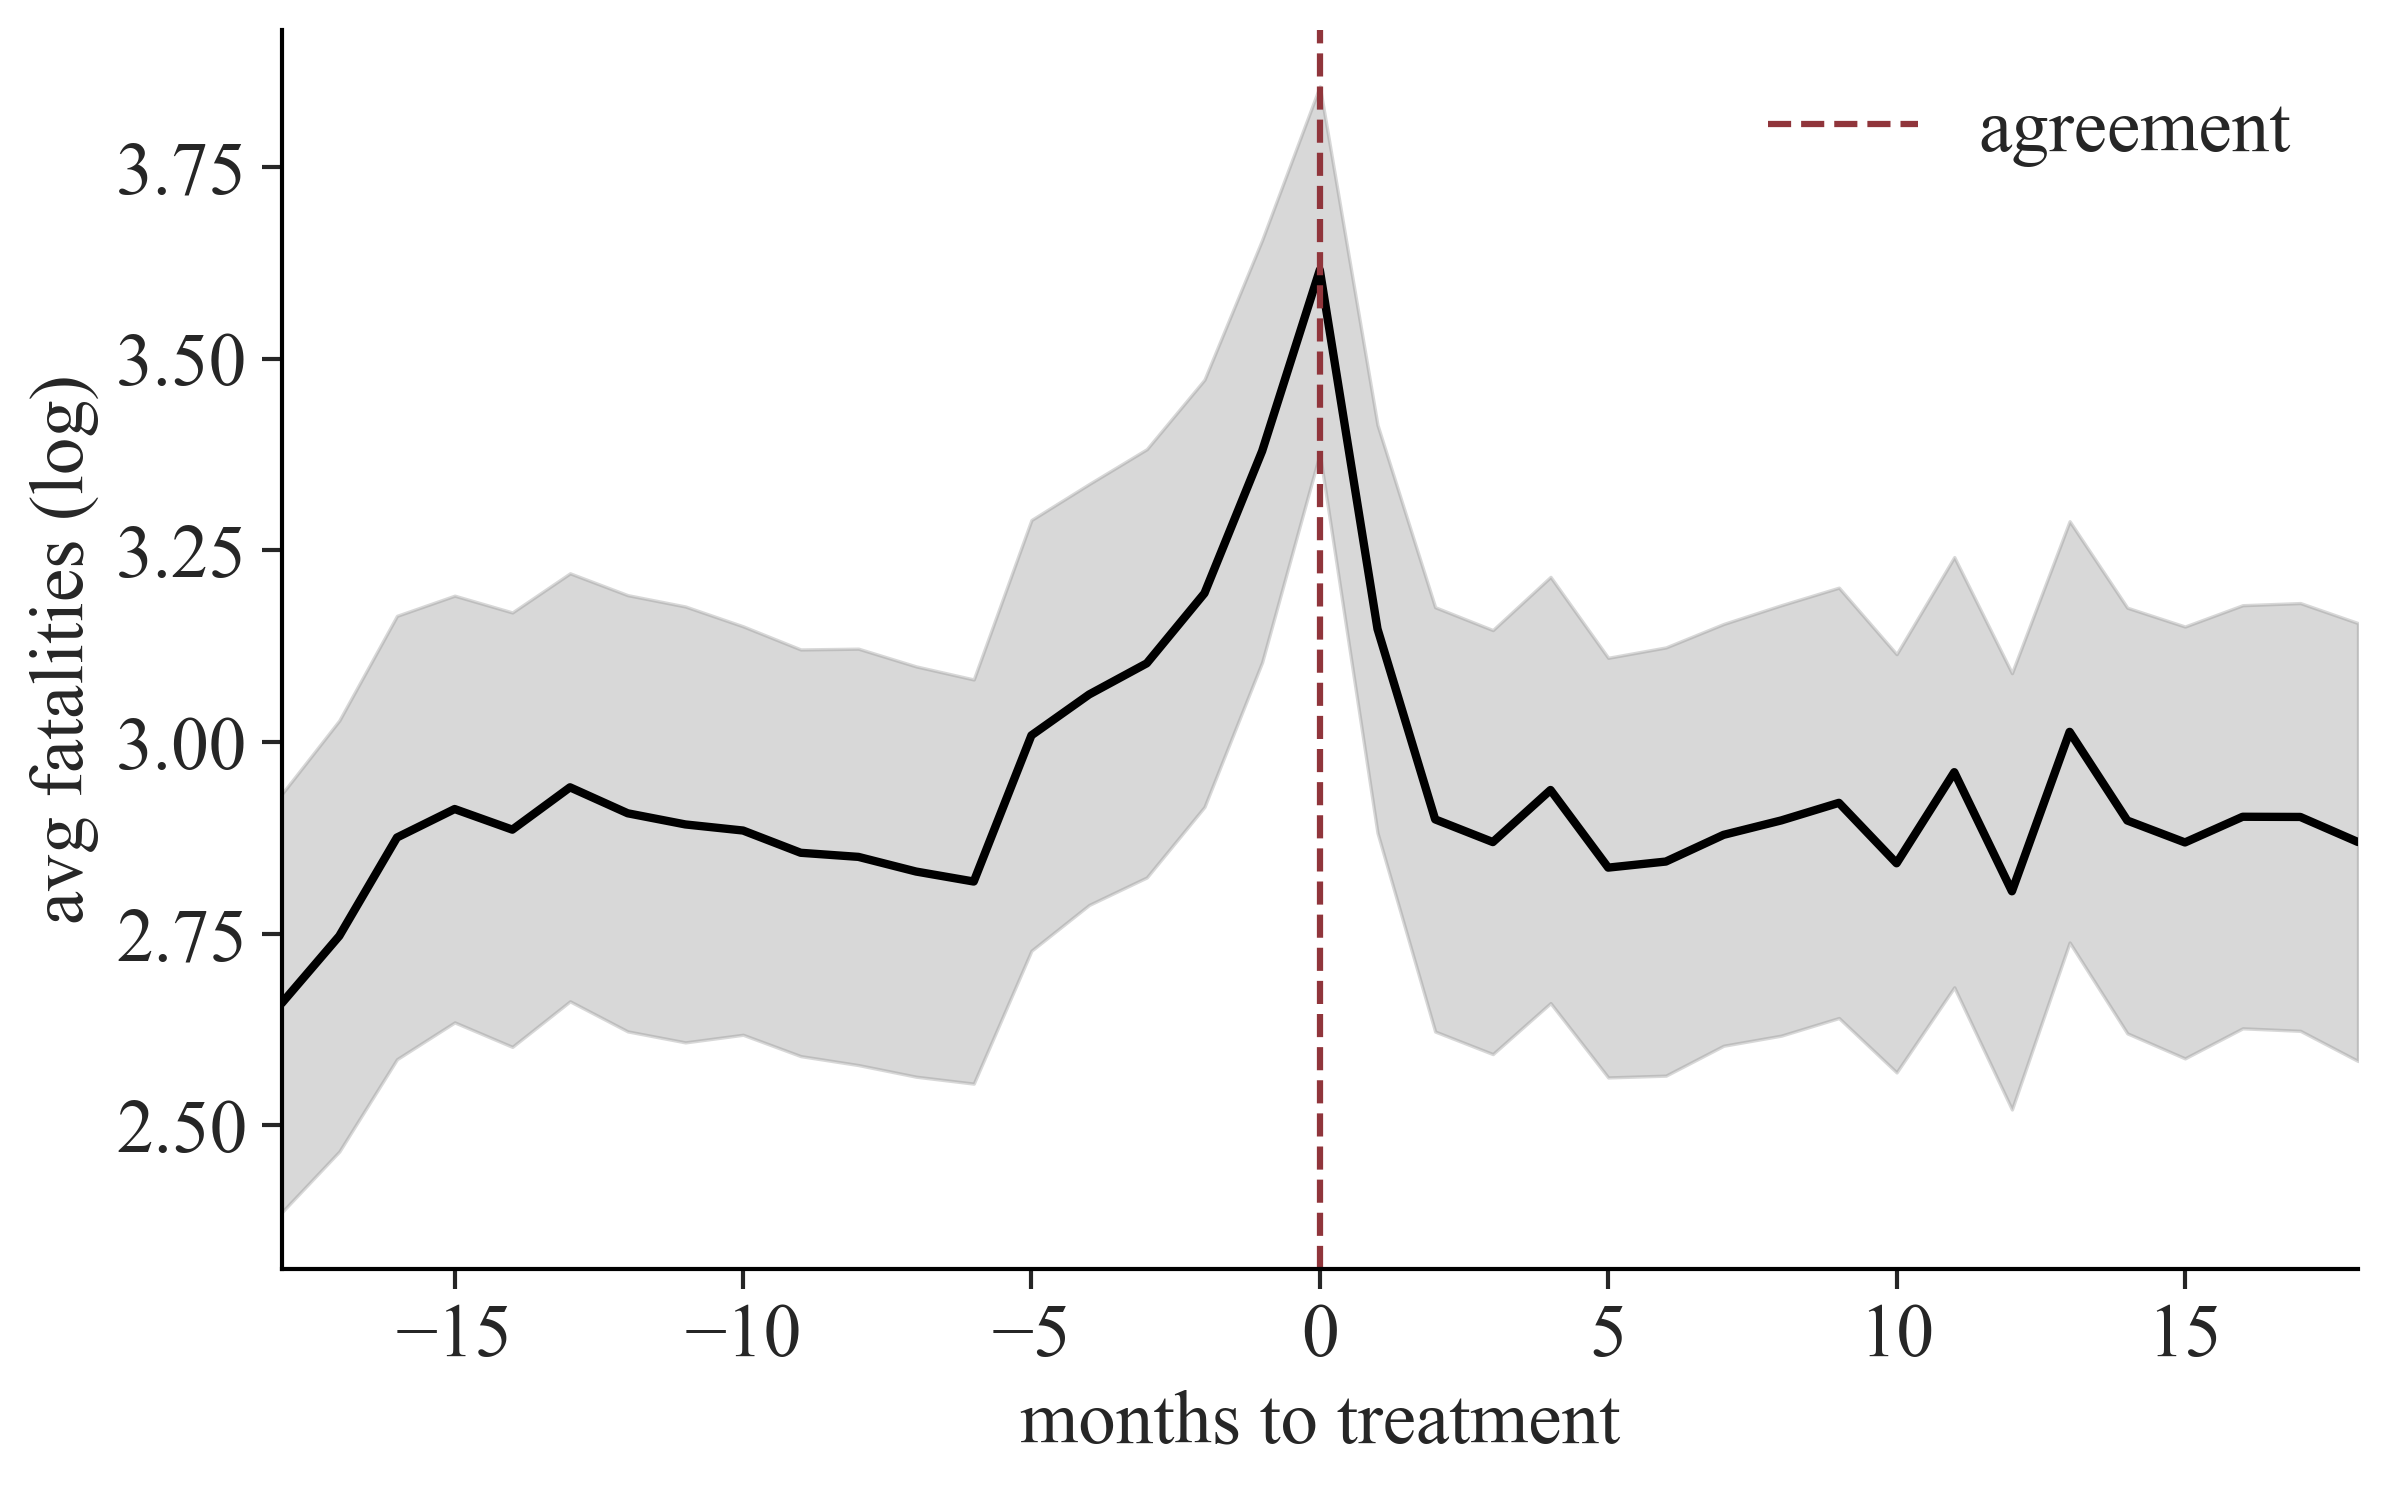

In [4]:
out = plot_agreement_mediation_event_studies(
    df_country,
    window=18,
    min_gap_multiplier=1,
    figsize=(8, 5),
    savepath='figures/event_study_agreement_18_window.png',
    treatment='agreement',
)


These plots help to visualize the selection problem we had in our main analysis. The outcome of analysis suffers from mean reversion, that can be seen in both figures. 

Even after conditioning on <code>armed_conflict</code>, or <code>civil_war</code>, the fatalities tend to decrease. 

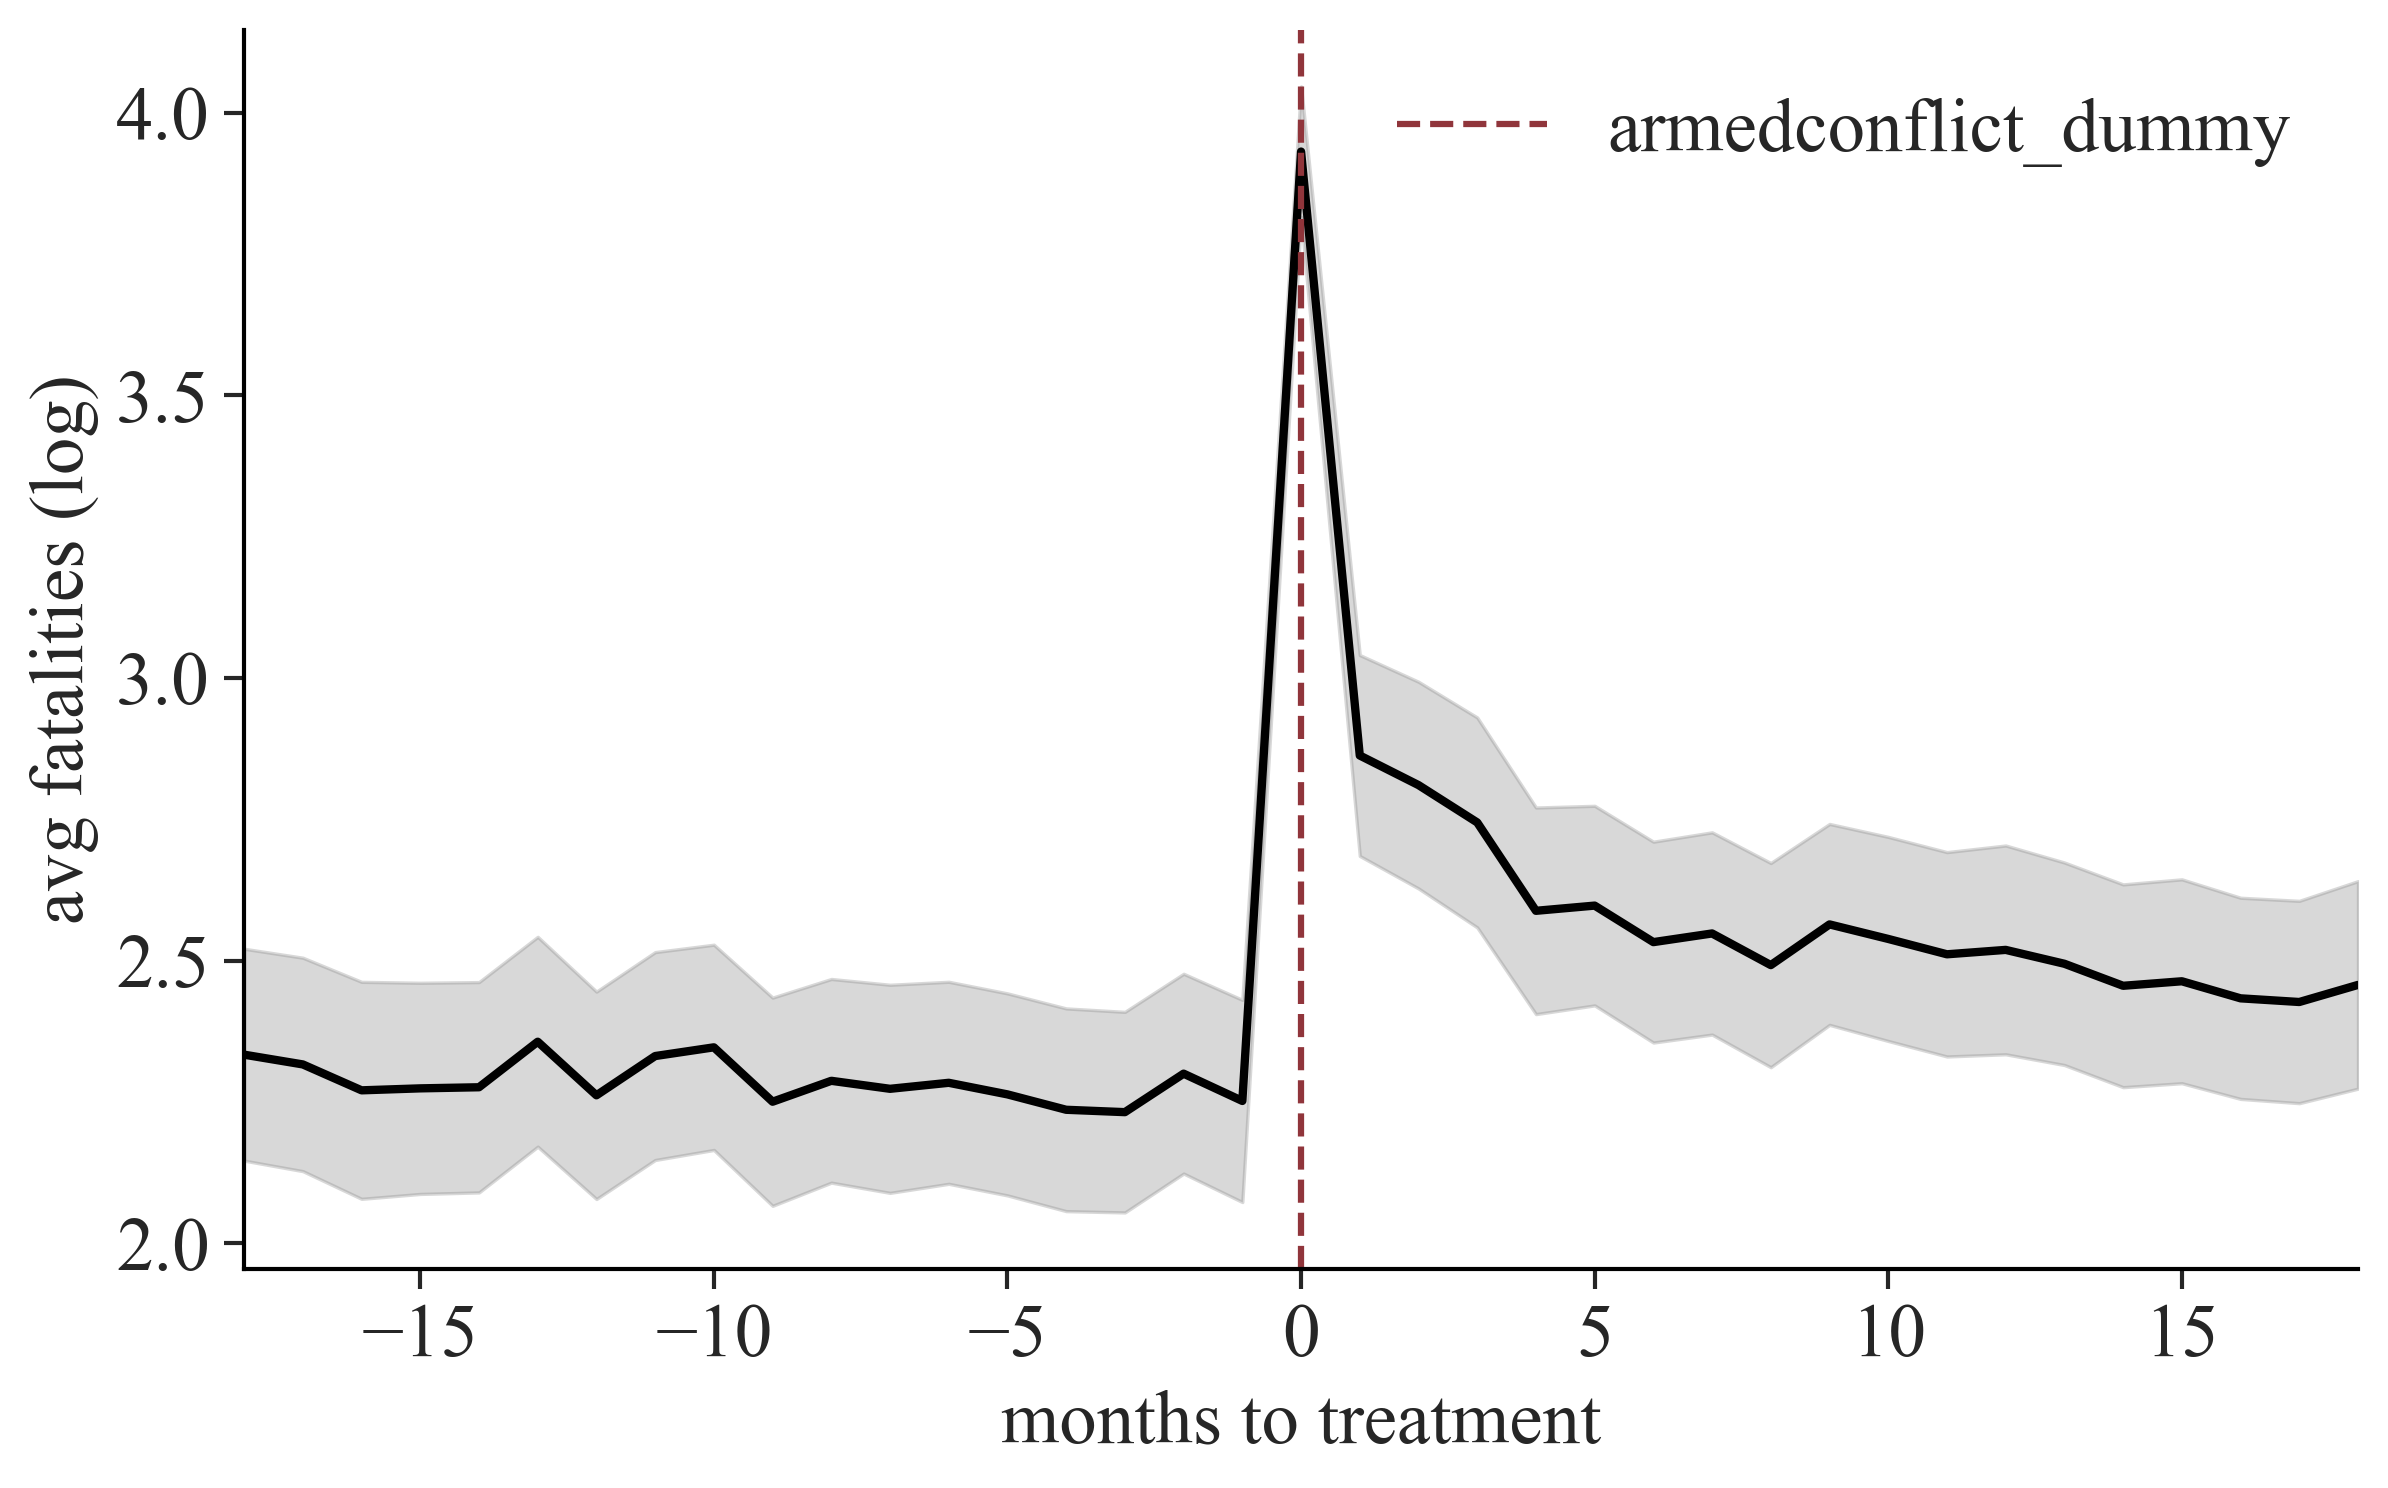

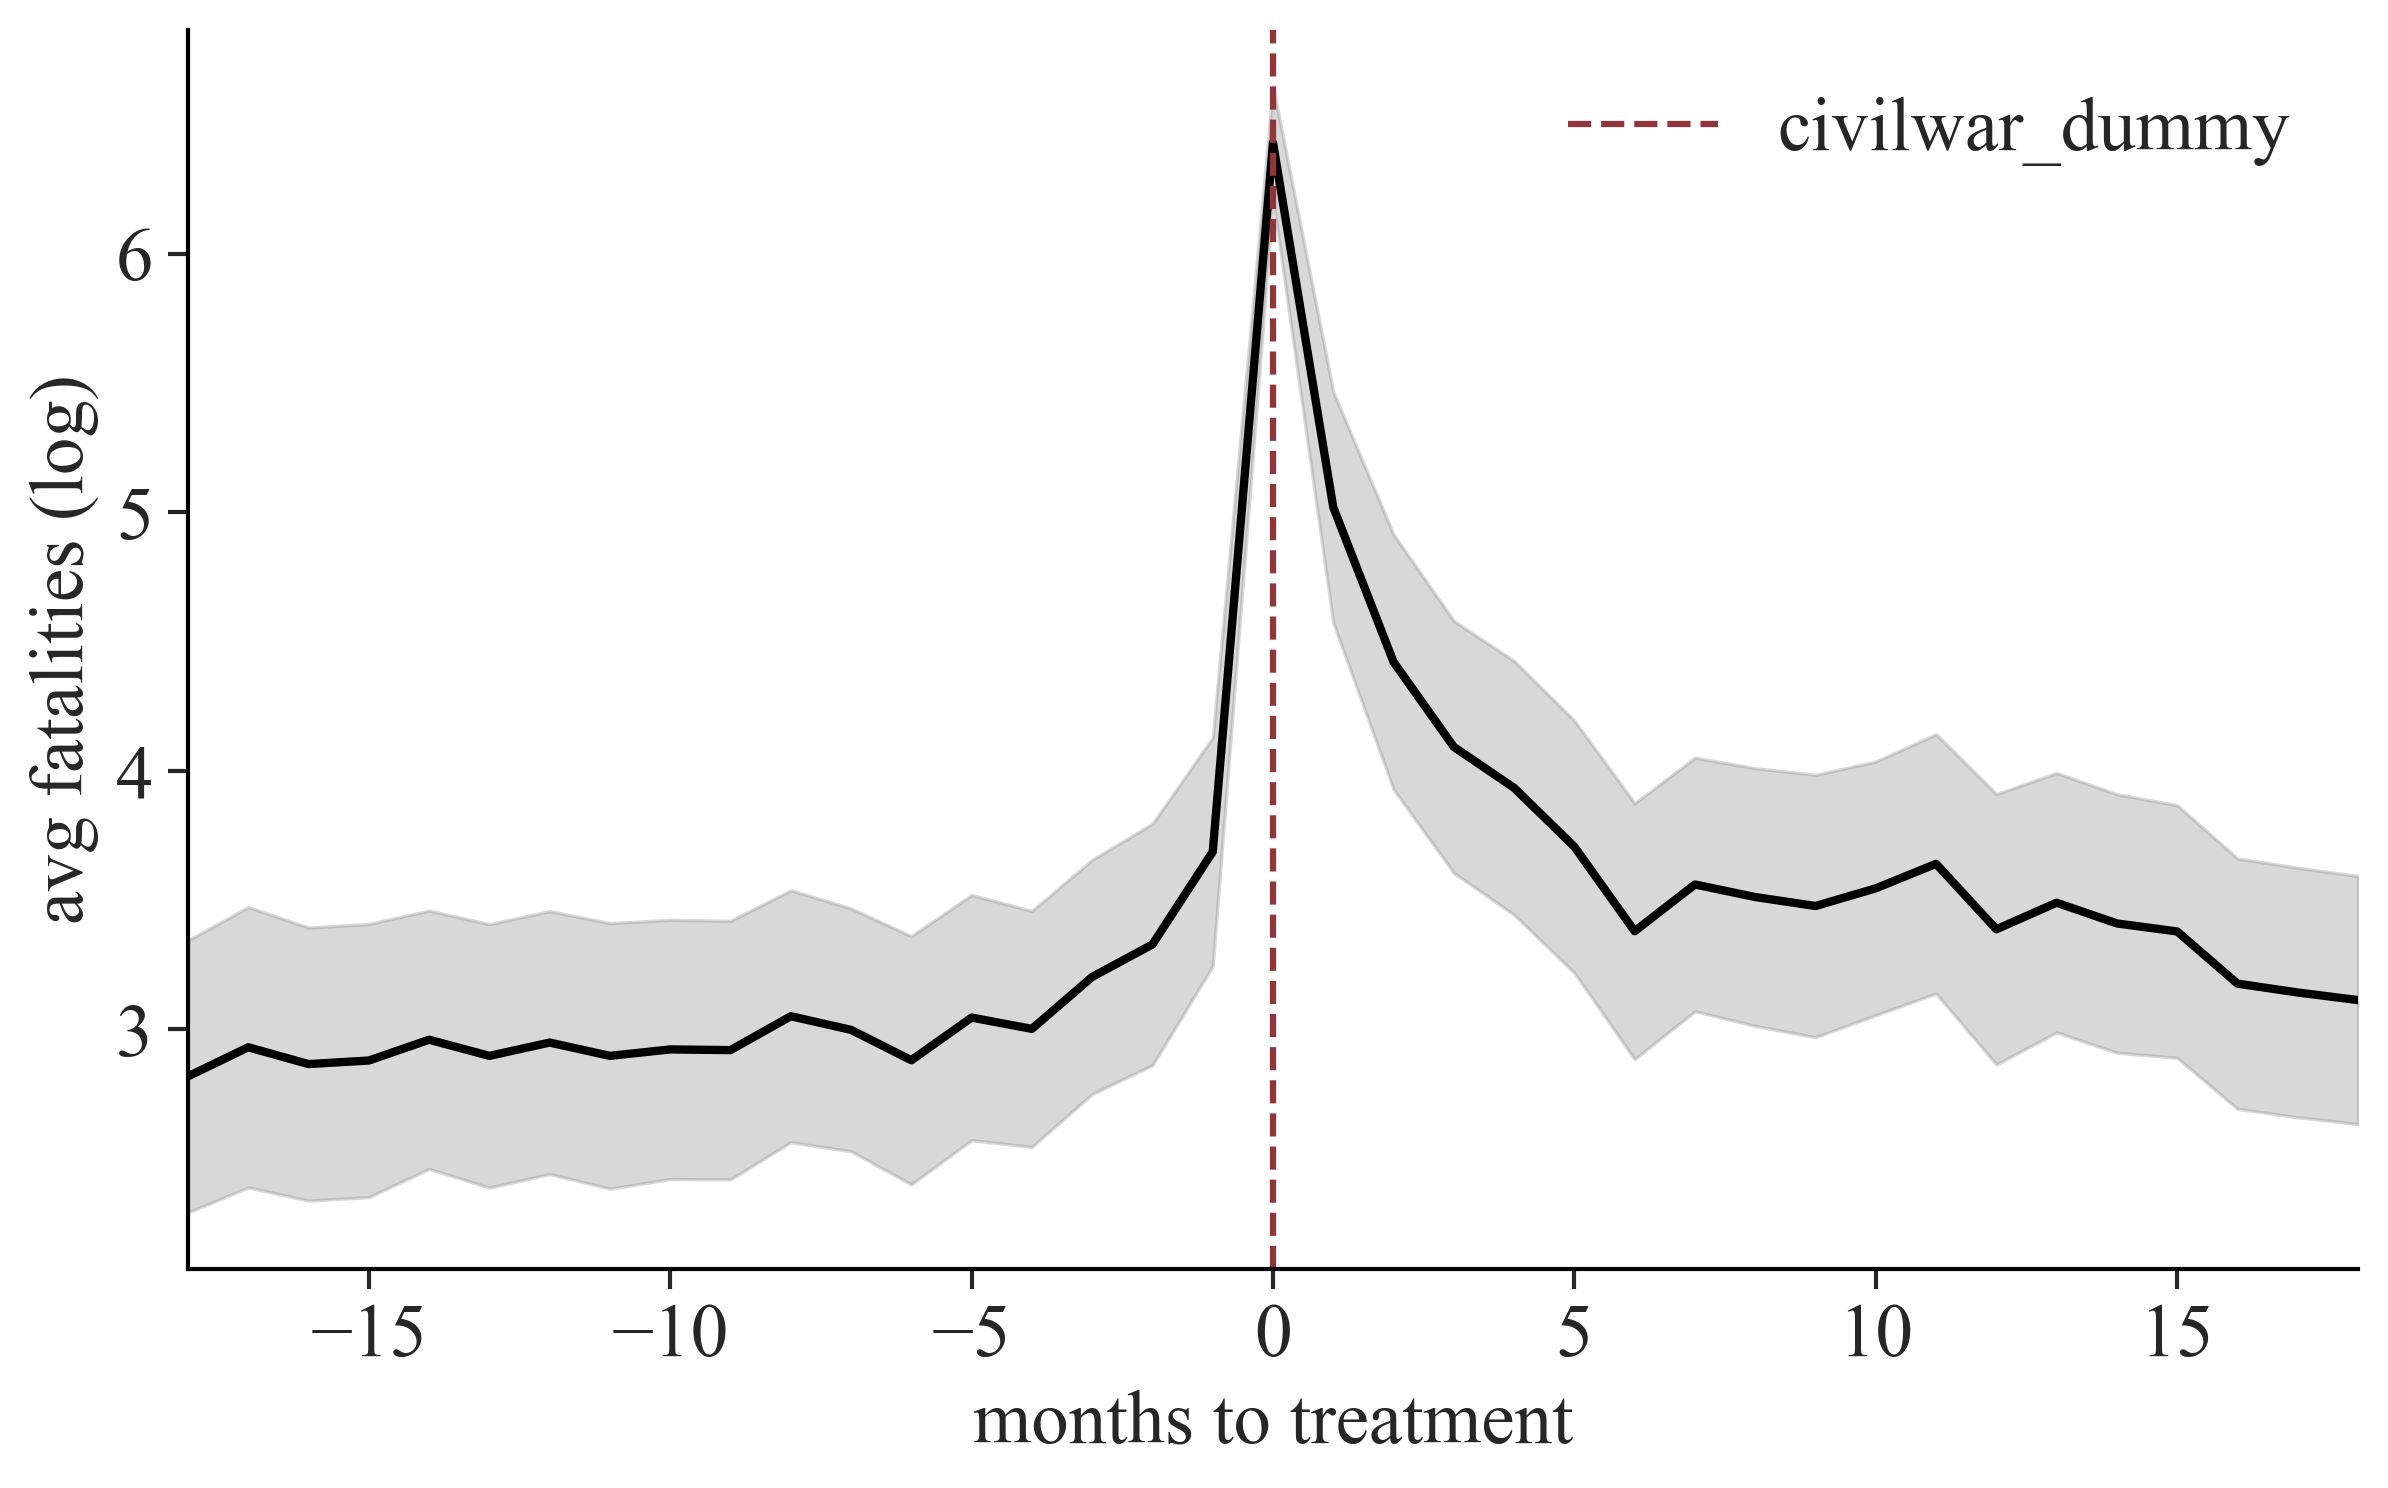

In [5]:
# #need to construct best_per_1M
pop = pd.read_csv('../../data/input/gdp_pc/gdp_pc.csv')
pop['year_mo'] = pd.to_datetime(pop['year_mo'])
df_country["year_mo"] = pd.to_datetime(df_country["year_mo"])
df_country = df_country.merge(pop, on=['isocode', 'year_mo'], how='left')
df_country
df_country['best_per_1M'] = df_country['best'] / (df_country['population'] / 1_000_000)
#create armedconflict dummy if 'best_per_1M' > 0.5
df_country['armedconflict_dummy'] = (df_country['best_per_1M'] > 0.5).astype(int)
#create civilwar_dummy dummy if 'best_per_1M' > 30
df_country['civilwar_dummy'] = (df_country['best_per_1M'] > 30).astype(int)

out = plot_agreement_mediation_event_studies(df_country, 
                                             window=18, 
                                             min_gap_multiplier=1, 
                                             figsize=(8, 5),
                                             savepath='figures/event_study_armedconflict_dummy.png',
                                             treatment='armedconflict_dummy')

out = plot_agreement_mediation_event_studies(df_country, 
                                             window=18, 
                                             min_gap_multiplier=1, 
                                             figsize=(8, 5),
                                             savepath='figures/event_study_civilwar_dummy.png',
                                             treatment='civilwar_dummy')

# Conflict Panel Analysis


1. How many conflict id do we have from UCDP
2. Show that the conflicts that sign agreements are only the ones with type of violence 1 and 2
3. Distribution of conflict duration
4. Distribution of number of agreements signed per conflict
5. How many conflicts sign agreements per year


### **Count of number of agreement and conflicts by ceasefire provisions**

In [12]:
df_panel = pd.read_csv('../../data/output/conflict_level/conflict_panel.csv', low_memory=False)
df_panel.loc[df_panel['cea_agreement']==1].groupby('ce')['conflict_id'].nunique().reset_index()

,ce,conflict_id
0,0.0,2
1,1.0,11
2,2.0,30
3,3.0,38


In [38]:
for treatment in [ 'agreement', 'comp_agreement', 'subs_agreement', 'cea_agreement',]:
    print('Treatment', treatment)
    print(df_panel[df_panel[treatment] == 1].groupby('ce').size().reset_index(name='n_agreements'))

Treatment agreement
    ce  n_agreements
0  0.0           290
1  1.0           119
2  2.0           201
3  3.0           135
Treatment comp_agreement
    ce  n_agreements
0  0.0            21
1  1.0             3
2  2.0            12
3  3.0            20
Treatment subs_agreement
    ce  n_agreements
0  0.0            99
1  1.0            27
2  2.0            36
3  3.0            28
Treatment cea_agreement
    ce  n_agreements
0  0.0             3
1  1.0            32
2  2.0            88
3  3.0           103


In [27]:
df_pax = pd.read_csv('../../data/input/pax/pax_data_2144_agreements_v9_10.csv', low_memory=False)
df_pax.columns = df_pax.columns.str.lower()

# conflicts that exist in your panel
ucdp_conflicts = df_panel['conflict_id'].dropna().unique()

# keep only PAX agreements tied to those conflicts
df_pax_ucdp = df_pax[df_pax['ucdpcon'].isin(ucdp_conflicts)].copy()

# example for comprehensive agreements
df_pax_ucdp['comp_agreement'] = (df_pax_ucdp['stage'].str.lower() == 'subcomp').astype(int)

df_pax_ucdp.loc[df_pax_ucdp['comp_agreement'] == 1] \
    .groupby('ce')['agtid'] \
    .nunique() \
    .reset_index(name='n_agreements')


,ce,n_agreements
0,0,49
1,1,6
2,2,18
3,3,23
